1. Harika
2. Abhay Vyas
3. Adib Azam Shaikh
4. Anand S
5. Bhavana Ganagani
6. Dharaneeswar Reddy
7. Dharshan gowda
8. Dudekula Sadhika
9. Durgesh Singh
10. MADHANKUMAR R
11. Jahnavi Gorla
12. Jashwanth Prabakhar
13. jeevana kani
14. Jegathesh Saravanan
15. kaipa rajavardhan
16. Konduru Varshitha
17. Kuruva Sandhya
18. Madhesh
19. mallelly sastha
20. Manikanta Reddy
21. Monil Panchal
22. Penugonda Praneeth
23. Poorna gopal bobba
24. Praneetha Kesa
25. Prem kumar Thota
26. Prudhvi Chitneedi
27. Puja Lokku
28. Rabia Begum
29. Revanth sai Pulluri
30. Sachi
31. Sania
32. Santhosh Unikili
33. Saranya Eslavath
34. Satvendra Giri Nihal Badam
35. Sneha Potluri
36. Sri vardhan
37. Srilatha Reddy Konkala
38. Steffi Rajan
39. Sukeerti Draksha
40. Swarna
41. YESWANTH M


In [1]:
!ls

flipkart_sales_data.xlsx  sample_data


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing  import MaxAbsScaler, StandardScaler, MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_excel('flipkart_sales_data.xlsx')
# df.drop(columns=['Order ID', 'Order Date'], inplace=True)
df.head(10)

,Order ID,Product Category,Sales Amount,Quantity Sold,Order Date,Region,Customer Rating,Payment Method,Discount (%)
0,ORD_1,Home Decor,16295.0,2.0,2023-01-01 00:00:00,East,1.5,UPI,10.0
1,ORD_2,Beauty & Health,1360.0,5.0,2023-01-01 12:00:00,West,3.1,Credit Card,15.0
2,ORD_3,Electronics,5890.0,1.0,2023-01-02 00:00:00,Central,1.5,Net Banking,5.0
3,ORD_4,Home Decor,12464.0,7.0,2023-01-02 12:00:00,South,2.1,UPI,5.0
4,ORD_5,Grocery,11784.0,1.0,2023-01-03 00:00:00,South,1.2,COD,10.0
5,ORD_6,Electronics,6765.0,4.0,2023-01-03 12:00:00,Central,3.8,Net Banking,15.0
6,ORD_7,Toys & Baby,17350.0,9.0,2023-01-04 00:00:00,South,2.8,Credit Card,15.0
7,ORD_8,Toys & Baby,4926.0,1.0,2023-01-04 12:00:00,East,4.6,COD,5.0
8,ORD_9,Fashion,14923.0,4.0,2023-01-05 00:00:00,Central,3.8,Net Banking,5.0
9,ORD_10,Beauty & Health,11863.0,6.0,2023-01-05 12:00:00,South,2.0,Net Banking,25.0


In [4]:
print("shape of dataset", df.shape)
print("\n")
df.info()

shape of dataset (1006, 9)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          1006 non-null   object        
 1   Product Category  1000 non-null   object        
 2   Sales Amount      1004 non-null   float64       
 3   Quantity Sold     1000 non-null   float64       
 4   Order Date        1000 non-null   datetime64[ns]
 5   Region            1004 non-null   object        
 6   Customer Rating   1000 non-null   float64       
 7   Payment Method    1000 non-null   object        
 8   Discount (%)      1000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 70.9+ KB


In [5]:
df.describe()

,Sales Amount,Quantity Sold,Order Date,Customer Rating,Discount (%)
count,1004.000000,1000.000000,1000,1000.000000,1000.00000
mean,10085.825697,4.924000,2023-09-07 17:59:59.999999744,3.016100,14.45000
min,509.000000,1.000000,2023-01-01 00:00:00,1.000000,5.00000
25%,5383.500000,3.000000,2023-05-05 21:00:00,2.000000,10.00000
50%,9835.000000,5.000000,2023-09-07 18:00:00,3.000000,15.00000
75%,14657.750000,7.000000,2024-01-10 15:00:00,4.000000,20.00000
max,19992.000000,9.000000,2024-05-14 12:00:00,5.000000,25.00000
std,5574.530275,2.612479,NaN,1.164675,7.30074


In [6]:
print("missing values per col")
print(df.isnull().sum())
print("\n")
print("total missing values", df.isnull().sum().sum())

missing values per col
Order ID            0
Product Category    6
Sales Amount        2
Quantity Sold       6
Order Date          6
Region              2
Customer Rating     6
Payment Method      6
Discount (%)        6
dtype: int64


total missing values 40


In [8]:
#fill the numerical values
num_cols = df.select_dtypes(include=np.number).columns
# print(num_cols)

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

print("missing values per col")
print(df.isnull().sum())
print("\n")
print("total missing values", df.isnull().sum().sum())

missing values per col
Order ID            0
Product Category    6
Sales Amount        0
Quantity Sold       0
Order Date          6
Region              2
Customer Rating     0
Payment Method      6
Discount (%)        0
dtype: int64


total missing values 20


/tmp/ipykernel_2863/1855740203.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [10]:
cat_cols = df.select_dtypes(include='object').columns
# print(cat_cols)
for col in cat_cols:
  df[col] = df[col].fillna(df[col].mode()[0])


print("missing values per col")
print(df.isnull().sum())
print("\n")
print("total missing values", df.isnull().sum().sum())


missing values per col
Order ID            0
Product Category    0
Sales Amount        0
Quantity Sold       0
Order Date          6
Region              0
Customer Rating     0
Payment Method      0
Discount (%)        0
dtype: int64


total missing values 6


In [12]:
date_cols = df.select_dtypes(include=['datetime']).columns
print(date_cols)

for col in date_cols:
  df[col] = df[col].ffill()


print("missing values per col")
print(df.isnull().sum())
print("\n")
print("total missing values", df.isnull().sum().sum())

Index(['Order Date'], dtype='object')
missing values per col
Order ID            0
Product Category    0
Sales Amount        0
Quantity Sold       0
Order Date          0
Region              0
Customer Rating     0
Payment Method      0
Discount (%)        0
dtype: int64


total missing values 0


In [13]:
#wrong data
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Date']

,Order Date
0,2023-01-01 00:00:00
1,2023-01-01 12:00:00
2,2023-01-02 00:00:00
3,2023-01-02 12:00:00
4,2023-01-03 00:00:00
...,...
1001,2024-05-14 12:00:00
1002,2024-05-14 12:00:00
1003,2024-05-14 12:00:00
1004,2024-05-14 12:00:00


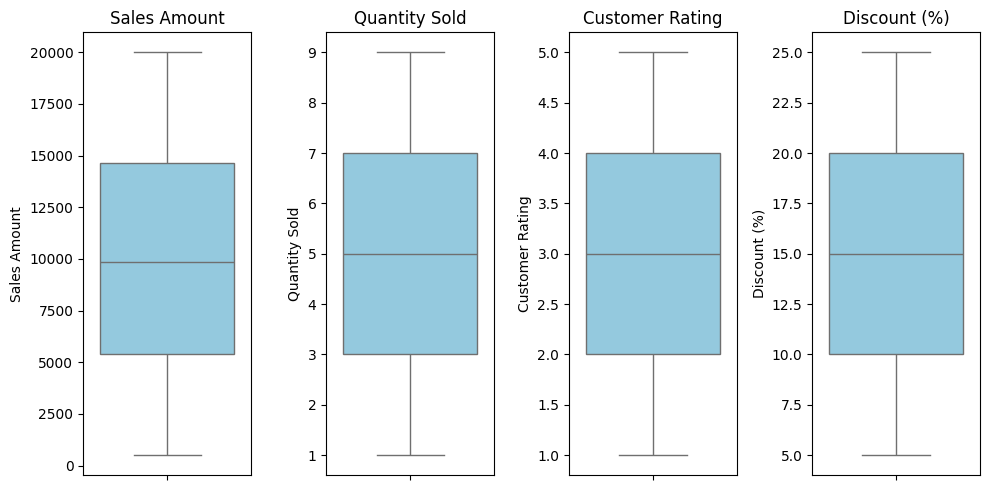

In [15]:
#showing outlier with boxplot

plt.figure(figsize=(10,5))
for i, col in enumerate(num_cols):
  plt.subplot(1,4,i+1)
  sns.boxplot(y = df[col], color = 'skyblue')
  plt.title(col)
  plt.tight_layout()

plt.show()

In [ ]:
#IQR by your own

In [16]:
#check the dublicates
print(df.duplicated().sum())

0


In [ ]:
#Categorical encoding

In [ ]:
#Feature scaling  ---standard scaler